**dN/dS**

Found 14 summary genes.txt files
  Processing kpneumoniae
  Processing ecoli
  Processing paeruginosa
  Processing mtuberculosis
  Processing cjejuni
  Processing nmeningitidis
  Processing sepidermidis
  Processing hinfluenzae
  Processing saureus
  Processing styphimurium
  Processing spneumoniae
  Processing lmonocytogenesA
  Processing bpertussis
  Processing sagalactiae

Summary written to /home/jovyan/shared-team/2025-masters-project/people/eleanor/original_and_processed_files/processed_c/charts/dnds/snpeff_summary_c.csv
        species  synonymous  nonsynonymous  syn_sites  nonsyn_sites  dN/dS
    kpneumoniae       28569          27957 1178877.33    3669548.67 0.3144
          ecoli       13230          16147  983573.67    3200646.33 0.3751
    paeruginosa        6757           8653 1592784.33    4741724.67 0.4302
  mtuberculosis       10545          17170 1046528.67    2951769.33 0.5773
        cjejuni        2196           3888  307005.67    1221119.33 0.4451
  nmeningitidis  

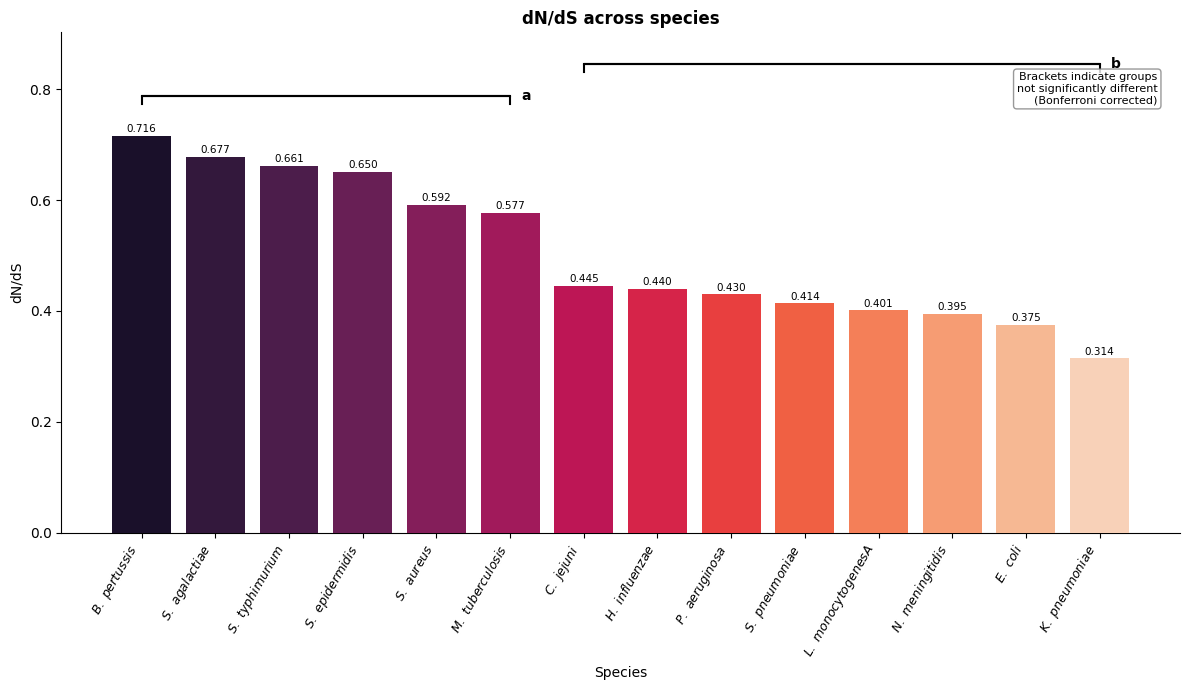


Plot saved to /home/jovyan/shared-team/2025-masters-project/people/eleanor/original_and_processed_files/processed_c/charts/dnds/dnds.png


In [8]:
import os
import glob
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests

# define paths
snpeff_folder = os.path.expanduser(
    "~/shared-team/2025-masters-project/people/eleanor/non_synon/snpEff/data/summaries"
)
fasta_folder = os.path.expanduser(
    "~/shared-team/2025-masters-project/people/eleanor/original_and_processed_files"
)
output_folder = os.path.expanduser(
    "~/shared-team/2025-masters-project/people/eleanor/original_and_processed_files/processed_c/charts/dnds/"
)
os.makedirs(output_folder, exist_ok=True)

output_csv = os.path.join(output_folder, "snpeff_summary_c.csv")
stats_csv  = os.path.join(output_folder, "dnds_stats.csv")

DPI = 300

# codon table to help define synon/non synon
codon_table = {
    'TTT': 'F', 'TTC': 'F', 'TTA': 'L', 'TTG': 'L',
    'CTT': 'L', 'CTC': 'L', 'CTA': 'L', 'CTG': 'L',
    'ATT': 'I', 'ATC': 'I', 'ATA': 'I', 'ATG': 'M',
    'GTT': 'V', 'GTC': 'V', 'GTA': 'V', 'GTG': 'V',
    'TCT': 'S', 'TCC': 'S', 'TCA': 'S', 'TCG': 'S',
    'CCT': 'P', 'CCC': 'P', 'CCA': 'P', 'CCG': 'P',
    'ACT': 'T', 'ACC': 'T', 'ACA': 'T', 'ACG': 'T',
    'GCT': 'A', 'GCC': 'A', 'GCA': 'A', 'GCG': 'A',
    'TAT': 'Y', 'TAC': 'Y', 'TAA': '*', 'TAG': '*',
    'CAT': 'H', 'CAC': 'H', 'CAA': 'Q', 'CAG': 'Q',
    'AAT': 'N', 'AAC': 'N', 'AAA': 'K', 'AAG': 'K',
    'GAT': 'D', 'GAC': 'D', 'GAA': 'E', 'GAG': 'E',
    'TGT': 'C', 'TGC': 'C', 'TGA': '*', 'TGG': 'W',
    'CGT': 'R', 'CGC': 'R', 'CGA': 'R', 'CGG': 'R',
    'AGT': 'S', 'AGC': 'S', 'AGA': 'R', 'AGG': 'R',
    'GGT': 'G', 'GGC': 'G', 'GGA': 'G', 'GGG': 'G',
}
BASES = ['A', 'T', 'C', 'G']


###############
#define functions
#load fasta and find sequences
def load_fasta(fasta_file):
    sequences     = {}
    current_chrom = None
    current_seq   = []
    with open(fasta_file) as f:
        for line in f:
            if line.startswith(">"):
                if current_chrom is not None:
                    sequences[current_chrom] = "".join(current_seq)
                current_chrom = line.strip().lstrip(">").split()[0]
                current_seq   = []
            else:
                current_seq.append(line.strip().upper())
    if current_chrom is not None:
        sequences[current_chrom] = "".join(current_seq)
    return sequences

#load cds from GFF file as list of coordinates
def load_cds(gff_file):
    cds_list = []
    with open(gff_file) as f:
        for line in f:
            if line.startswith("#"):
                continue
            cols = line.strip().split("\t")
            if len(cols) < 9 or cols[2] != "CDS":
                continue
            cds_list.append((cols[0], int(cols[3]) - 1, int(cols[4]), cols[6]))
    return cds_list

def reverse_complement(seq):
    complement = {"A": "T", "T": "A", "C": "G", "G": "C"}
    return "".join(complement.get(b, "N") for b in reversed(seq))

#count sites at codons on all possible mutations to get opportunities 
def count_sites(codon):
    syn_sites    = 0.0
    nonsyn_sites = 0.0
    for pos in range(3):
        ref_base = codon[pos]
        ref_aa   = codon_table.get(codon)
        if ref_aa is None:
            continue
        syn = nonsyn = 0
        for alt_base in BASES:
            if alt_base == ref_base:
                continue
            mut_codon = codon[:pos] + alt_base + codon[pos+1:]
            alt_aa    = codon_table.get(mut_codon)
            if alt_aa is None:
                continue
            if alt_aa == ref_aa:
                syn += 1
            else:
                nonsyn += 1
        total = syn + nonsyn
        if total > 0:
            syn_sites    += syn / total
            nonsyn_sites += nonsyn / total
    return syn_sites, nonsyn_sites

#sum these opportunities 
def calculate_opportunities(cds_list, sequences):
    total_syn    = 0.0
    total_nonsyn = 0.0
    for chrom, start, end, strand in cds_list:
        seq = sequences.get(chrom, "")
        if not seq:
            continue
        cds_seq = seq[start:end]
        if strand == "-":
            cds_seq = reverse_complement(cds_seq)
        for i in range(0, len(cds_seq) - 2, 3):
            codon = cds_seq[i:i+3]
            if len(codon) != 3 or "N" in codon:
                continue
            s, n = count_sites(codon)
            total_syn    += s
            total_nonsyn += n
    return total_syn, total_nonsyn

#find summary gene files from snpEff and return synon and nonsynon counts
def parse_genes_txt(filepath):
    synonymous    = 0
    nonsynonymous = 0
    with open(filepath) as f:
        headers = None
        for line in f:
            if line.startswith("##") or line.strip() == "":
                continue
            if line.startswith("#"):
                headers = line.lstrip("#").strip().split("\t")
                continue
            if headers is None:
                continue
            cols = line.strip().split("\t")
            row  = dict(zip(headers, cols))
            if row.get("BioType", "") != "protein_coding":
                continue
            synonymous    += int(row.get("variants_effect_synonymous_variant", 0))
            nonsynonymous += (
                int(row.get("variants_effect_missense_variant",  0)) +
                int(row.get("variants_effect_stop_gained",       0)) +
                int(row.get("variants_effect_stop_lost",         0)) +
                int(row.get("variants_effect_start_lost",        0))
            )
    return synonymous, nonsynonymous

def format_species(name):
    return f"$\\it{{{name[0].upper()}.\\ {name[1:]}}}$"

#for CLD: draw brackets for graph
def draw_bracket(ax, x_left, x_right, y, tick_h, ltr):
    ax.plot([x_left, x_right], [y, y],
            color="black", lw=1.5, clip_on=False)
    ax.plot([x_left, x_left, x_right, x_right],
            [y - tick_h, y, y, y - tick_h],
            color="black", lw=1.5, clip_on=False)
    ax.text(x_right + 0.15, y, ltr,
            ha="left", va="center", fontsize=10, fontweight="bold")

#compute compact letter display for graph from pairwise    
def compute_cld(species_list, pair_df, value_series):
    ordered  = value_series.sort_values(ascending=False).index.tolist()
    alphabet = "abcdefghijklmnopqrstuvwxyz"
    #builds pairs that are not signficant
    ns_pairs = set()
    for _, row in pair_df[~pair_df["significant"]].iterrows():
        ns_pairs.add((row["species_1"], row["species_2"]))
        ns_pairs.add((row["species_2"], row["species_1"]))

    def shares_letter(group, sp):
        return all((sp, g) in ns_pairs for g in group)

    groups     = []
    letters    = []
    letter_idx = 0
    #place species in a group and build dictionary for graph
    for sp in ordered:
        placed = False
        for grp in groups:
            if shares_letter(grp, sp):
                grp.add(sp)
                placed = True
                break
        if not placed:
            groups.append({sp})
            letters.append(alphabet[letter_idx])
            letter_idx += 1

    cld_dict = {sp: "" for sp in species_list}
    for grp, ltr in zip(groups, letters):
        for sp in grp:
            cld_dict[sp] += ltr
    #used in graph to find which species is each letter where every pair is non-sig
    letter_to_species = {
        ltr: [sp for sp, ltrs in cld_dict.items() if ltr in ltrs]
        for ltr in letters
    }

    return cld_dict, letter_to_species, letters

def scale_to(values, target=1000):
    total = values.sum()
    return values / total * target if total > 0 else values

###########################
#find outputs from snpEff, find counts of synon and nonsynon
summary_rows = []
genes_files  = glob.glob(os.path.join(snpeff_folder, "*.genes.txt"))
print(f"Found {len(genes_files)} summary genes.txt files")

for genes_file in genes_files:
    species_name = os.path.basename(genes_file).split(".snpEff")[0]
    print(f"  Processing {species_name}")

    synonymous, nonsynonymous = parse_genes_txt(genes_file)
    
    #find fasta/gff files and use functions to load, find opportunities from cds sites
    fasta_file = os.path.join(fasta_folder, f"{species_name}.fna")
    gff_file   = os.path.join(fasta_folder, f"{species_name}.gff")

    sequences  = load_fasta(fasta_file)
    cds_list   = load_cds(gff_file)
    syn_sites, nonsyn_sites = calculate_opportunities(cds_list, sequences)

    #define dn/ds 
    dS   = synonymous    / syn_sites      
    dN   = nonsynonymous / nonsyn_sites 
    dnds = (dN / dS) 

    summary_rows.append([
        species_name, synonymous, nonsynonymous,
        round(syn_sites,    2),
        round(nonsyn_sites, 2),
        round(dnds, 4)
    ])

#save as new csv
with open(output_csv, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["species", "synonymous", "nonsynonymous",
                     "syn_sites", "nonsyn_sites", "dN/dS"])
    writer.writerows(summary_rows)

print(f"\nSummary written to {output_csv}")


########################
#stats

df = pd.read_csv(output_csv)

for col in ["dN/dS", "syn_sites", "nonsyn_sites", "synonymous", "nonsynonymous"]:
    df[col] = pd.to_numeric(df[col])

SPECIES_LIST = sorted(df["species"].unique())
N_SPECIES    = len(SPECIES_LIST)

print(df[["species", "synonymous", "nonsynonymous",
          "syn_sites", "nonsyn_sites", "dN/dS"]].to_string(index=False))

df["syn_rate"]    = np.where(df["syn_sites"]    > 0,
                             df["synonymous"]    / df["syn_sites"],    0)
df["nonsyn_rate"] = np.where(df["nonsyn_sites"] > 0,
                             df["nonsynonymous"] / df["nonsyn_sites"], 0)

contingency        = df.set_index("species")[["syn_rate", "nonsyn_rate"]].loc[SPECIES_LIST]

#pairwise with bonf correction for each species pair, save 
pair_rows = []
for sp1, sp2 in combinations(SPECIES_LIST, 2):
    row1 = scale_to(contingency.loc[sp1].values)
    row2 = scale_to(contingency.loc[sp2].values)
    chi2_p, p_p, dof_p, _ = chi2_contingency(np.array([row1, row2]))
    pair_rows.append({
        "test": "1b_pairwise", "species_1": sp1, "species_2": sp2,
        "statistic": round(chi2_p, 4), "df": dof_p, "p_raw": p_p,
    })

pair_df                  = pd.DataFrame(pair_rows)
_, p_bonf, _, _          = multipletests(pair_df["p_raw"], method="bonferroni")
pair_df["p_corrected"]   = p_bonf.round(6)
pair_df["significant"]   = p_bonf < 0.05

pair_df.to_csv(stats_csv, index=False)
print(f"\nAll results saved to {stats_csv}")

#using functions find letters for compact letter display
dnds_series = df.set_index("species")["dN/dS"]
cld_dict, letter_to_species, cld_letters = compute_cld(
    SPECIES_LIST, pair_df, dnds_series
)

#############
#plot graph of dN/dS using values and cld, and colour scheme
df = df.sort_values("dN/dS", ascending=False).reset_index(drop=True)
df["species_fmt"] = df["species"].apply(format_species)
df["cld"]         = df["species"].map(cld_dict)

x_pos  = dict(zip(df["species"], range(len(df))))
colours = sns.color_palette("rocket", len(df))

fig, ax = plt.subplots(figsize=(12, 7))
ax.bar(df["species_fmt"], df["dN/dS"], color=colours, zorder=3)

for i, (_, row) in enumerate(df.iterrows()):
    ax.text(i, row["dN/dS"] + 0.003, f"{row['dN/dS']:.3f}",
            ha="center", va="bottom", fontsize=7.5)

y_max         = df["dN/dS"].max()
bracket_gap   = y_max * 0.08
bracket_start = y_max * 1.10
tick_h        = y_max * 0.02

#label cld and draw bracket, label axes and titles
for row_idx, ltr in enumerate(cld_letters):
    members = letter_to_species[ltr]
    if not members:
        continue
    xs = [x_pos[sp] for sp in members]
    draw_bracket(ax, min(xs), max(xs),
                 bracket_start + row_idx * bracket_gap,
                 tick_h, ltr)

n_letters = len(cld_letters)
ax.set_ylim(0, bracket_start + n_letters * bracket_gap)
ax.set_xticks(range(len(df)))
ax.set_xticklabels(df["species_fmt"], rotation=60, ha="right", fontsize=9)
ax.set_ylabel("dN/dS")
ax.set_xlabel("Species")
ax.set_title("dN/dS across species", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)

#legend
ax.text(0.98, 0.92,
        "Brackets indicate groups\nnot significantly different\n(Bonferroni corrected)",
        transform=ax.transAxes, fontsize=8, va="top", ha="right",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8, ec="grey"))
#save
plt.tight_layout()
out_path = os.path.join(output_folder, "dnds.png")
plt.savefig(out_path, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"\nPlot saved to {out_path}")